In [1]:
# 2 sample tets - population --> sample values 1 and sample values 2 --> mean of 1 sample and mean of 2nd sample
#then we'll compare those two values

#questions

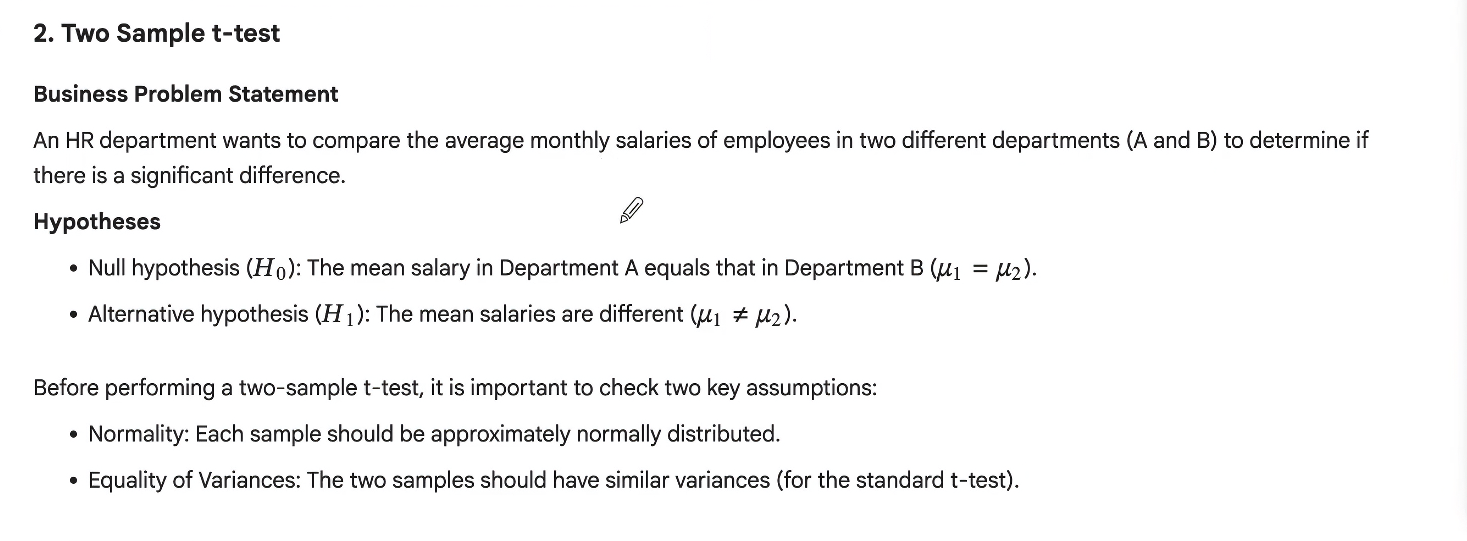

In [20]:
#more the values in sample more the data 
import numpy as np

# Monthly salaries in USD for two departments
dept_a = np.array([4500, 4700, 4200, 4800, 4600, 4400, 4550, 4650, 4750, 4300])
dept_b = np.array([4000, 4150, 4100, 3950, 4200, 4050, 4100, 4000, 4150, 4050])
#suppose we researched this data(asked each people) and got this sample data of 10 emplooyee salaray.

#before 2 sample text there are assumption :

 #Both the sample should be normally distributed
 #Both samples should have similar variances (for the standard t-test)



In [12]:
from scipy.stats import shapiro, ttest_ind
shapiro_stat_a , shapiro_p_value_a = shapiro(dept_a)
shapiro_stat_b , shapiro_p_value_b = shapiro(dept_b)

In [13]:
shapiro_p_value_a

0.7713665744080458

In [14]:
shapiro_p_value_b

0.8485975564649946

In [15]:
#both p values are greater than 0.05 hence they are normally distributed

In [19]:
#lenven test for equality of variances 
from scipy.stats import levene

#if the levene value is greater than 0.05 hence means variances are equal

levene_stat, levene_p_value = levene(dept_a,dept_b)
#if fam using function a running a test - they will give two things back which is test stats and p value 

levene_p_value

0.029281204462727414

In [24]:
#sample has two different variances hence our condition is failed 

tt_stat, t_p_value =ttest_ind(dept_a,dept_b,equal_var=False) 
#ttest_ind means ttest independent - equal variance is false - if it would then true 

In [25]:
t_p_value

1.4988271248674483e-05

In [26]:
#its less than 0.05 (5%)- hence we  have enough evidence to say that the null var is rejected
#its less cause -05 says 10 raise to the power minus 5 - 
#hence salaries are not same ! - diff

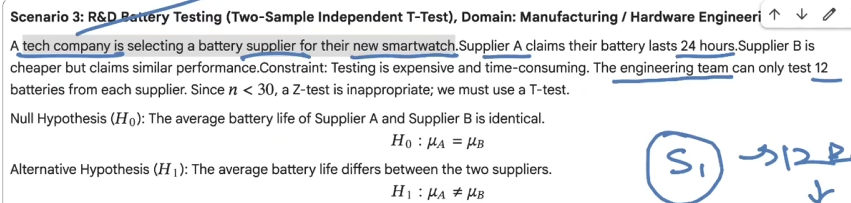

In [28]:
#we have 12 batteries from each supplier - we'll use t test
#lets see the samples

# 1. Data (Hours of battery life)
# Small sample sizes (n=12)
supplier_a = [24.1, 23.8, 24.5, 23.0, 24.2, 23.9, 24.0, 23.5, 24.8, 24.1, 23.7, 24.3]
supplier_b = [22.8, 23.1, 22.5, 23.0, 22.9, 23.5, 22.1, 23.3, 22.8, 23.0, 22.7, 23.4]

mean_a = np.mean(supplier_a)
print(mean_a)
mean_b = np.mean(supplier_b)
print(mean_b)

23.99166666666667
22.925


In [30]:
#these are the means now we have to check that if it is significant range or we have to reject the a- almost 1 hour difference

In [31]:
levene_stat2, p_valye_lev = levene(supplier_a,supplier_b)

In [33]:
p_valye_lev

0.6672974677115968

In [34]:
#it should be greater than 0.05 - it is greater than 0.05 hence same variance

In [36]:
#2nd condition -
#normal distribution
a_shapiro_stats , shapiro_pvalue_a = shapiro(supplier_a)
print(shapiro_pvalue_a)

0.9875073378105873


In [37]:
b_shapiro_stats , shapiro_pvalue_b = shapiro(supplier_b)
print(shapiro_pvalue_b)

0.878782891448451


In [38]:
#both are greater than 0.05 hence they both are normally distributed

In [40]:
#both conditions are correct hence
t2_stat,t2_pvalue=ttest_ind(supplier_a,supplier_b,equal_var=True)

In [41]:
print(t2_pvalue)

4.4011438572331546e-06


In [42]:
#it is less than 0.05 hence we can drop the null hypothesis
#so we'll be going to choose battery A

In [43]:
#ANOVA --> it is used where the sample are more than two and numerical

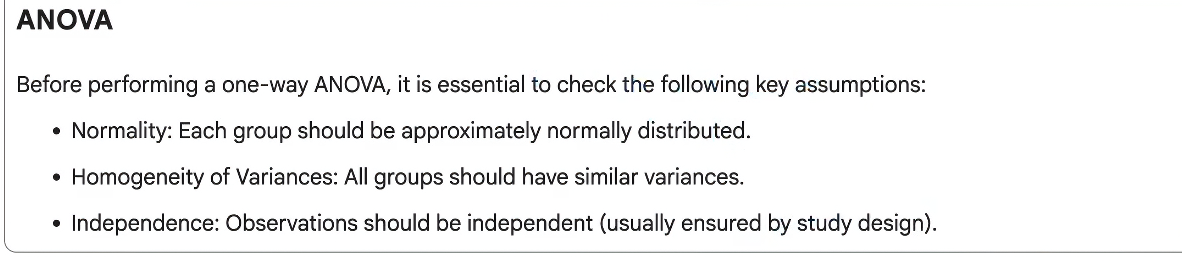

In [44]:
#samples should be independent from each others 

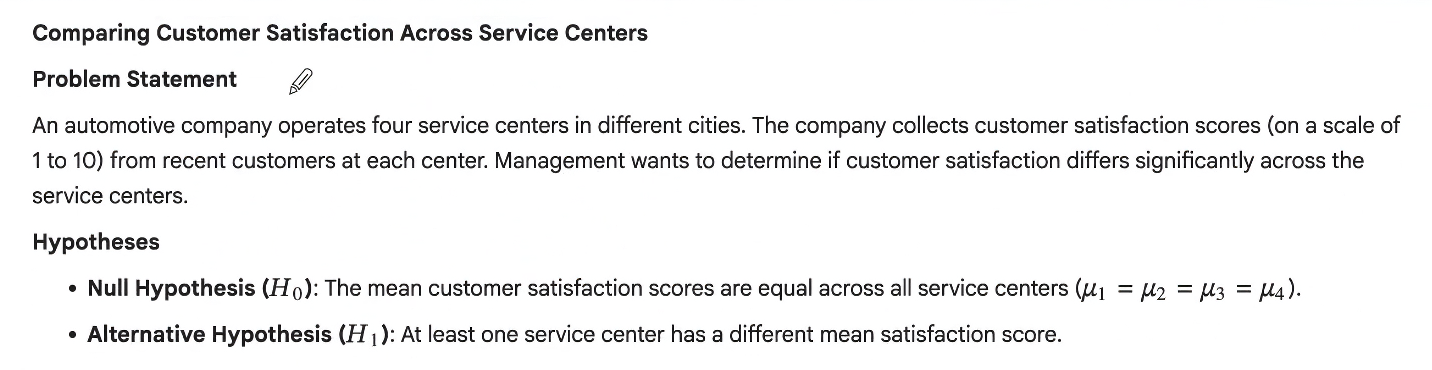

In [50]:
import numpy as np
from scipy.stats import f_oneway, shapiro, levene, kruskal

# Satisfaction scores for each service center
center_1 = np.array([8, 9, 7, 8, 9])
center_2 = np.array([6, 7, 6, 8, 7])
center_3 = np.array([9, 8, 9, 10, 9])
center_4 = np.array([7, 6, 7, 8, 7])

#these are the 4 samples we have to check if they equal or somewhat difference 

# 1. Check normality for each group (Shapiro-Wilk test)
print("Normality (Shapiro-Wilk):")
shapir_stat1 , shapir_pval1 = shapiro(center_1)
shapir_stat2 , shapir_pval2 = shapiro(center_2)
shapir_stat3 , shapir_pval3 = shapiro(center_3)
shapir_stat4 , shapir_pval4 = shapiro(center_4)
print(shapir_pval1)
print(shapir_pval2)
print(shapir_pval3)
print(shapir_pval4)

Normality (Shapiro-Wilk):
0.3140395561440371
0.3140395561440371
0.32542950716414576
0.32542950716414576


In [53]:
#all the values are more than 0.05 - means all are normally distributed

#checking for the same variance 
leve_stat , leve_pvalue = levene(center_1,center_2,center_3,center_4)
leve_pvalue

0.8795405391233022

In [54]:
#its greater than 0.05 means - all are values have same variance 

In [55]:
#and all the samples are independent as well - hence all conditions are met

In [56]:
f_stat, f_pvalue = f_oneway(center_1,center_2,center_3,center_4)
print('f stat is', f_stat,'f p value is ', f_pvalue)

f stat is 8.97222222222222 f p value is  0.0010184144192209974


In [57]:
#p value is less than 0.05 - which means that we can drop the null value cause we have enough evidence means all the showroom
#nreviews are not same

In [58]:
#out of these conditions any fails then we will use kruskal test !

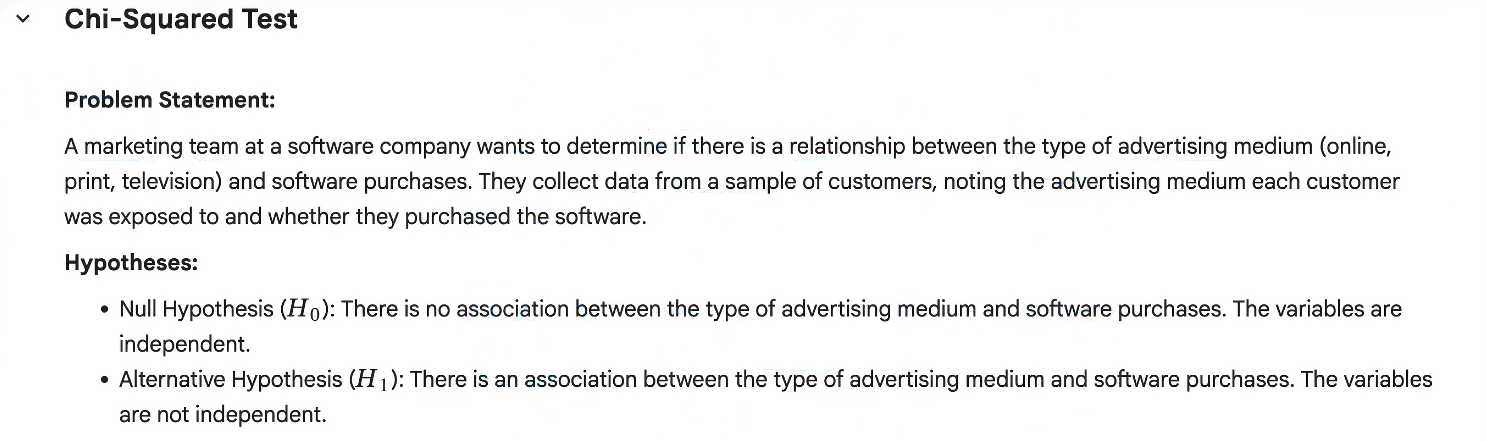

In [61]:
import numpy as np
from scipy.stats import chi2_contingency

# Observed frequency data in a contingency table
# Rows in the data array represent: Advertising Medium (Online, Print, Television)
# Columns in the data array represent: Purchase (Yes, No)
data = np.array([[30, 10],  # Online
                 [20, 20],  # Print
                 [50, 30]]) # Television

# Perform Chi-Square Test of Independence
chi2_stat, p_value, dof, expected = chi2_contingency(data)
print('chi statistics :' ,chi2_stat, 'p value is :', p_value)
if p_value < 0.05:
    print('we have sufficient evidence to drop the null hypothesis - saying all data are same')
else:
    print('we dont have enough evidence to drop the null; hypothesis')

chi statistics : 5.333333333333334 p value is : 0.0694834512228015
we dont have enough evidence to drop the null; hypothesis


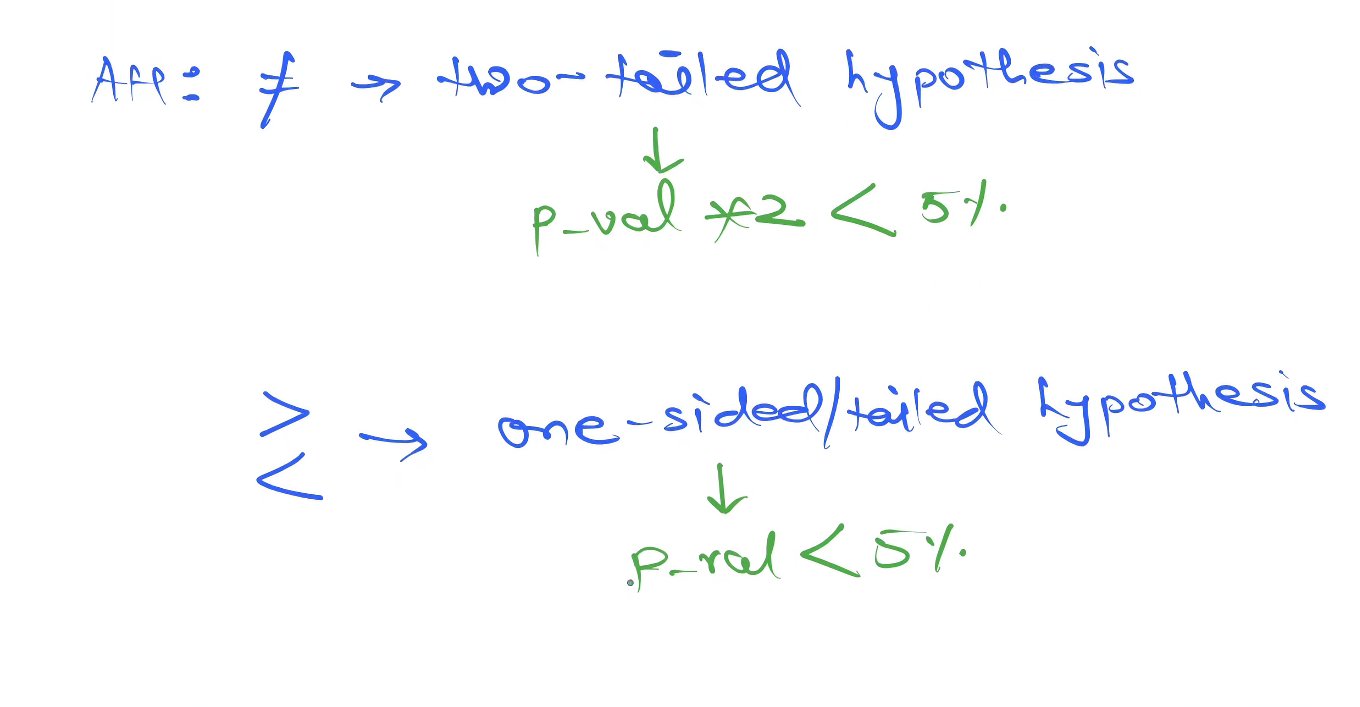

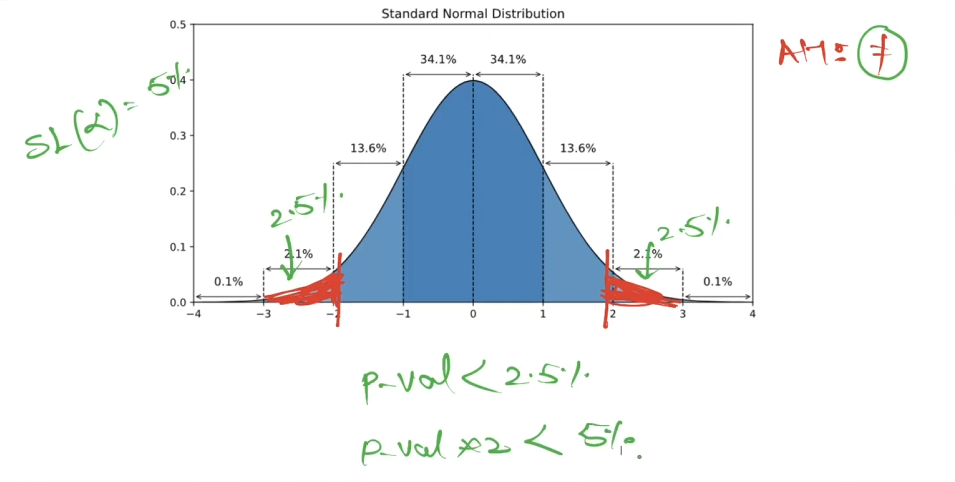

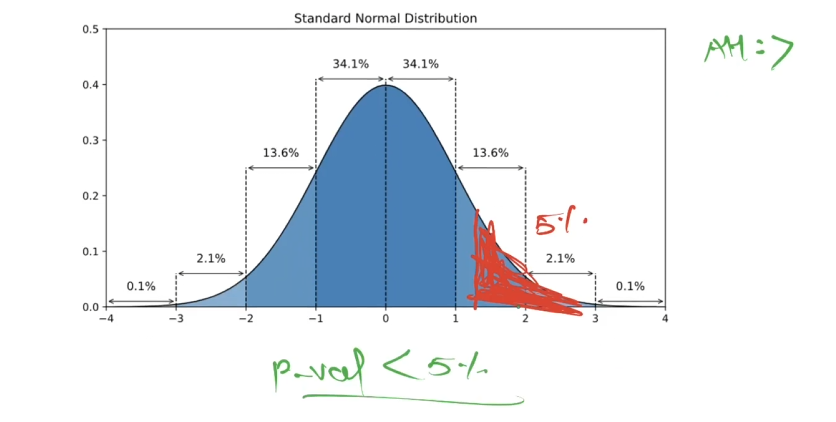